# TrustCV – IID Methods Showcase

This notebook demonstrates how to **check and test each IID method separately**
in the TrustCV toolkit:

- `HoldOut`
- `KFold`
- `StratifiedKFold`
- `RepeatedKFold`
- `LOOCV`
- `LPOCV`
- `MonteCarloCV`
- `BootstrapValidation`
- `NestedCV` (nested CV with inner hyperparameter tuning)

We use:
- A standard sklearn dataset (`load_breast_cancer`)
- A simple `StandardScaler + RandomForestClassifier` pipeline
- Diffrent metrics


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer, make_classification
from matplotlib.patches import Patch

# Import TrustCV components
import trustcv
from trustcv.splitters import (
    HoldOut, 
    KFold, 
    StratifiedKFold, 
    RepeatedKFold, 
    BootstrapValidation, 
    MonteCarloCV, 
    LeaveOneOut, 
    LeavePOut
)
from trustcv import TrustCVValidator

print(f"TrustCV Version: {trustcv.__version__}")

TrustCV Version: 1.0.1


## 2. Load Dataset



We will use the **Breast Cancer Wisconsin** dataset, a classic medical binary classification task.

Python

In [2]:
data = load_breast_cancer()
X, y = data.data, data.target

# Create a small imbalanced subset for clearer visualization of LOOCV/LPOCV
X_small, y_small = make_classification(n_samples=25, n_classes=2, weights=[0.7, 0.3], random_state=42)

print(f"Full Dataset: {X.shape}, Class Balance: {np.bincount(y)}")
print(f"Small Dataset: {X_small.shape}, Class Balance: {np.bincount(y_small)}")

Full Dataset: (569, 30), Class Balance: [212 357]
Small Dataset: (25, 20), Class Balance: [18  7]


## 3. Visualization Utility



This helper function visualizes the indices chosen for training (blue) and testing (orange) across splits.

Python

In [113]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from math import comb
from sklearn.datasets import load_breast_cancer, make_classification
from trustcv.splitters import LPOCV

# --- 1. Define the Correct Plotting Function for LPOCV ---
def plot_cv_detailed(cv, X, y, ax, n_splits, lw=10):
    """
    Visualizes Standard CV splits (like LPOCV, KFold).
    0 (Red)  = Test Set
    1 (Blue) = Training Set
    """
    # Simple Binary Colormap: 0 -> Red, 1 -> Blue
    cmap = ListedColormap(['#FF9999', '#66B2FF'])
    
    # Generate the training/testing visualizations for each CV split
    for ii, (tr, te) in enumerate(cv.split(X, y)):
        # Initialize mask: 1 = Train, 0 = Test
        indices = np.array([np.nan] * len(X))
        indices[tr] = 1 
        indices[te] = 0 
        
        # Visualize rows
        ax.scatter(range(len(indices)), [ii + .5] * len(indices),
                   c=indices, marker='s', s=150, cmap=cmap,
                   vmin=0, vmax=1, edgecolors='none')

    # Formatting
    ax.set_yticks(np.arange(n_splits) + .5)
    ax.set_yticklabels([f"Split {i+1}" for i in range(n_splits)])
    ax.set_xlabel('Sample index')
    ax.set_ylim(n_splits, 0) # Invert Y axis so Split 1 is at top
    
    # --- Correct Legend for Standard CV/LPOCV ---
    legend_elements = [
        Patch(facecolor='#66B2FF', label='Training Set'),
        Patch(facecolor='#FF9999', label='Test Set (Left Out)')
    ]
    # Place legend outside
    ax.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left')
    return ax

#

## 4. Method-by-Method Testing





### A. Hold-Out Validation



The simplest method: splits data once into train and test sets.

- **Use case:** Large datasets where CV is too expensive, or simple prototyping.

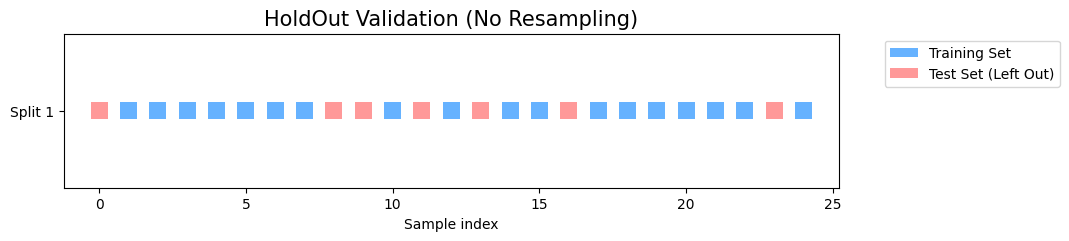

Train: 18, Test: 7 (Total: 25)


In [114]:
# Initialize
holdout = HoldOut(test_size=0.3, random_state=42)

# Visualize
fig, ax = plt.subplots(figsize=(10, 2))
plot_cv_detailed(holdout, X_small, y_small, ax, n_splits=1)

ax.set_title('HoldOut Validation (No Resampling)', fontsize=15)
plt.show()

# Verify sizes
for train, test in holdout.split(X_small, y_small):
    print(f"Train: {len(train)}, Test: {len(test)} (Total: {len(train)+len(test)})")

### Total data

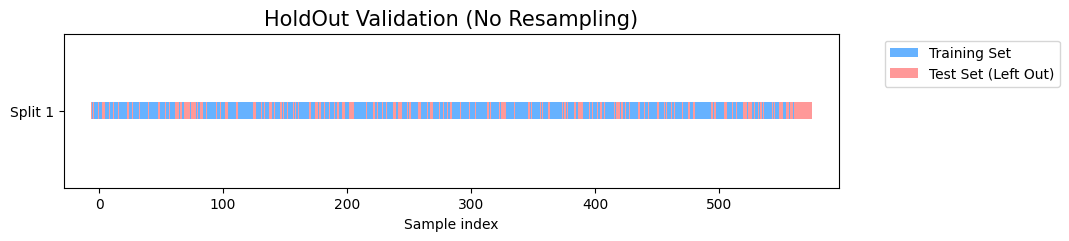

Train: 399, Test: 170 (Total: 569)


In [115]:

# Initialize
holdout = HoldOut(test_size=0.3, random_state=42)

# Visualize
fig, ax = plt.subplots(figsize=(10, 2))
plot_cv_detailed(holdout, X, y, ax, n_splits=1)
ax.set_title('HoldOut Validation (No Resampling)', fontsize=15)
plt.show()

# Verify sizes
for train, test in holdout.split(X, y):
    print(f"Train: {len(train)}, Test: {len(test)} (Total: {len(train)+len(test)})")

### B. K-Fold Cross-Validation



Splits data into `k` consecutive folds. Each fold is used once as validation while the `k-1` remaining folds form the training set.

- **Use case:** Standard evaluation for I.I.D. data.



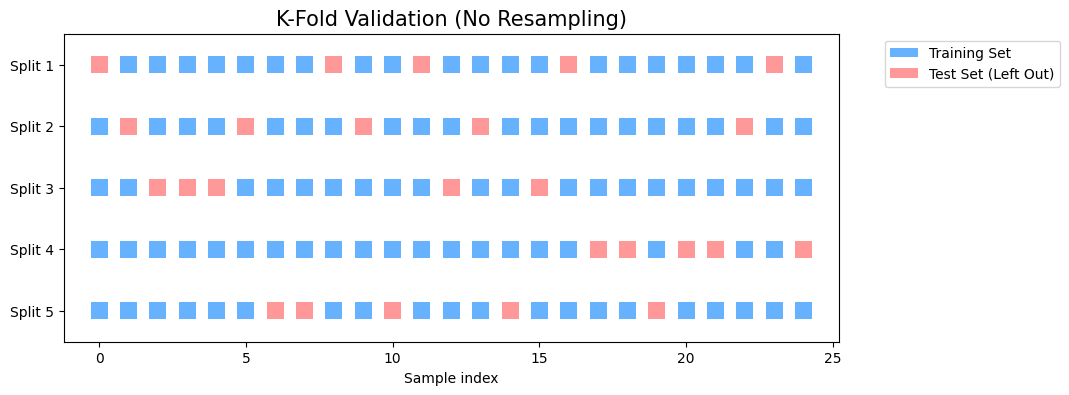

In [116]:
# Initialize
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Visualize
fig, ax = plt.subplots(figsize=(10, 4))
plot_cv_detailed(cv, X_small, y_small, ax, n_splits=5)
ax.set_title('K-Fold Validation (No Resampling)', fontsize=15)
plt.show()

### C. Stratified K-Fold (Medical Recommended)



Same as K-Fold, but preserves the percentage of samples for each class. **Crucial for medical data** with rare diseases.

Class distribution per fold:
  Fold 1: 62.28% positive class (Global: 62.74%)
  Fold 2: 62.28% positive class (Global: 62.74%)
  Fold 3: 63.16% positive class (Global: 62.74%)
  Fold 4: 63.16% positive class (Global: 62.74%)
  Fold 5: 62.83% positive class (Global: 62.74%)


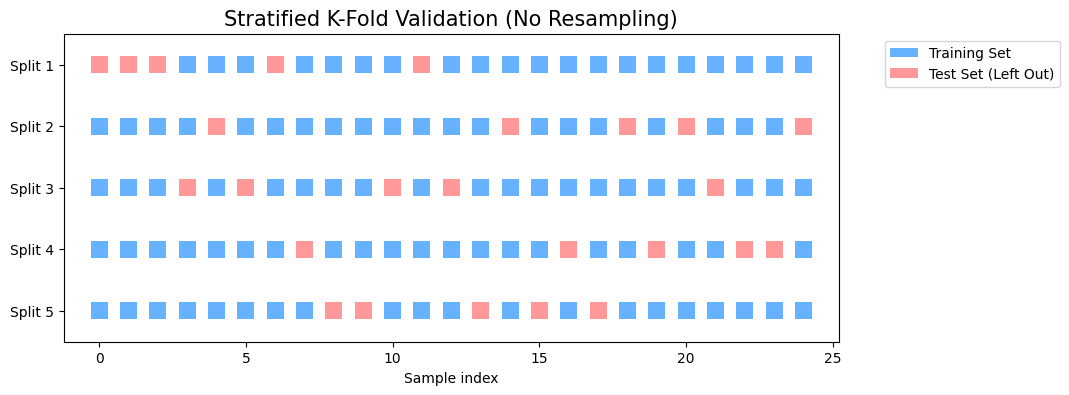

In [117]:
# Initialize
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Check balance preservation
print("Class distribution per fold:")
for i, (train, test) in enumerate(cv.split(X, y)):
    balance = np.mean(y[test])
    print(f"  Fold {i+1}: {balance:.2%} positive class (Global: {np.mean(y):.2%})")

# Visualize
fig, ax = plt.subplots(figsize=(10, 4))
plot_cv_detailed(cv, X_small, y_small, ax, n_splits=5)
ax.set_title('Stratified K-Fold Validation (No Resampling)', fontsize=15)
plt.show()



### D. Repeated K-Fold



Runs K-Fold `n_repeats` times with different randomizations. Reduces variance in the error estimate.

- **Use case:** Small-to-medium medical datasets where result stability is key.

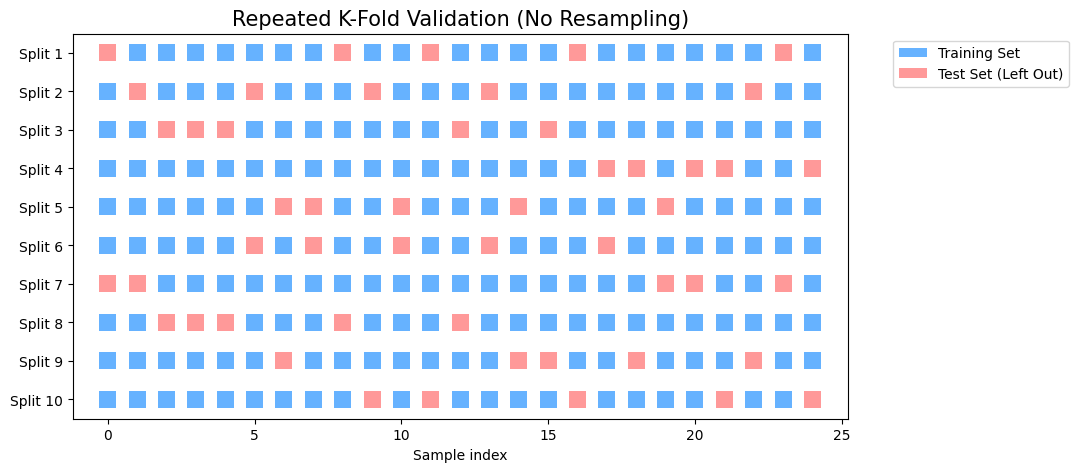

In [118]:
# Initialize (2 repeats of 5 folds = 10 total splits)
cv = RepeatedKFold(n_splits=5, n_repeats=2, random_state=42)

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
plot_cv_detailed(cv, X_small, y_small, ax, n_splits=10)
ax.set_title('Repeated K-Fold Validation (No Resampling)', fontsize=15)
plt.show()

### E. Monte Carlo CV (Shuffle-Split)



Randomly splits data into train/test sets `n_iterations` times. Unlike K-Fold, test sets can overlap.

- **Use case:** Flexible control over `test_size` independent of the number of iterations.



### How to Interpret the Plot



1. **Randomness:** Unlike K-Fold, the "Red" test blocks don't form a perfect diagonal line. They are scattered randomly because every iteration shuffles the data anew.
2. **Overlap Risk:** You might see that some samples (columns) are **Red (Test)** multiple times, while others might be **Red** only once or never. This is the key difference from K-Fold: K-Fold guarantees every sample is tested exactly once; Monte-Carlo does not.
3. **Flexibility:** You can change `test_size` to 0.5 or 0.1 and immediately see the ratio of Red vs. Blue change in the plot, which helps verify that your split sizes are correct.


### Conceptual Comparison Repeated K-Fold vs Monte-Carlo CV 



| **Feature**            | **Repeated K-Fold**                                          | **Monte-Carlo CV (Shuffle-Split)**                           |
| ---------------------- | ------------------------------------------------------------ | ------------------------------------------------------------ |
| **Coverage Guarantee** | **Yes.** Every sample is guaranteed to be tested exactly $N$ times (where $N$ is the number of repeats). | **No.** Some samples may be selected for the test set frequently, while others ("unlucky" samples) might never be tested. |
| **Test Set Overlap**   | **Controlled.** Within one K-Fold loop, test sets never overlap. They only overlap between repeats. | **Uncontrolled.** Test sets can overlap randomly between any two iterations. |
| **Train/Test Size**    | **Fixed.** Determined by $K$. (e.g., 5-Fold = 20% Test, 80% Train). You cannot change this freely. | **Flexible.** You can set *any* split ratio (e.g., 90% Train / 10% Test) regardless of how many iterations you run. |
| **Main Goal**          | Reducing variance of the error estimate while ensuring **fairness** (everyone gets tested equally). | Checking model stability under specific **constraints** (e.g., "how does it do if trained on exactly 50% of data?"). |



###  Why does this matter?



- **Use Repeated K-Fold when:** You want a robust, unbiased estimate of your model's performance. Because every data point is used in the test set the same number of times, no single "hard" data point dominates the error metric just by bad luck of random sampling.
- **Use Monte-Carlo CV when:** You have a very large dataset where running a full K-Fold is too slow, OR you need to specifically control the training size (e.g., learning curves) independent of the number of iterations. It is also useful if you want to run *thousands* of quick validation checks to get a probability distribution of results.


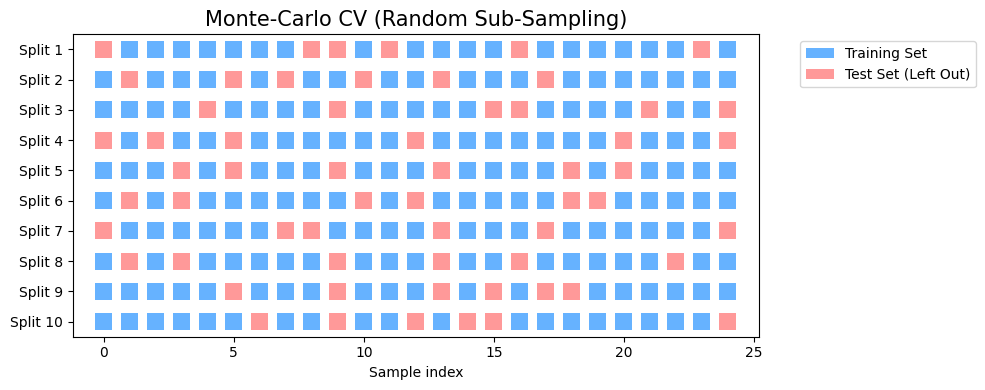

In [119]:
# Initialize
cv = MonteCarloCV(n_iterations=10, test_size=0.25, random_state=42)

# Visualize
fig, ax = plt.subplots(figsize=(10, 4))
plot_cv_detailed(cv, X_small, y_small, ax, n_splits=10)
ax.set_title('Monte-Carlo CV (Random Sub-Sampling)', fontsize=15)
plt.tight_layout()
plt.show()

### F. Bootstrap Validation



Samples training data *with replacement*. Test data is the "out-of-bag" (OOB) samples.

- **Use case:** Estimating confidence intervals; very small datasets.

### Why it looks different for K-Fold



Since K-Fold does **not** resample with replacement (it just splits the data), every sample appears in the training set exactly **once** or **zero** times.

- **0 (Red):** The sample is in the Test set.
- **1 (Light Blue):** The sample is in the Training set.
- **2+ (Dark Blue):** You will **never** see this for K-Fold, because K-Fold doesn't create duplicates.


**Relevant video :** It explains the mechanics of the .632 and .632+ methods, detailing how the bootstrap sampling with replacement creates the specific training/test distributions that this new plot visualizes [9.7 The .632 and .632+ Bootstrap methods (L09 Model Eval 2: Confidence Intervals)](https://www.youtube.com/watch?v=wb4_dEmhhgU).

In [120]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

def plot_bootcv_detailed(cv, X, y, ax, n_splits, lw=10):
    """
    Visualizes Bootstrap splits by showing frequency of selection.
    
    0 (Red)   = Out-of-Bag (Test Set)
    1+ (Blue) = In-Bag (Training Set, darker blue = more duplicates)
    """
    # Create a custom colormap: 
    # 0 -> Red (Test/OOB)
    # 1 -> Light Blue
    # 2 -> Medium Blue
    # 3+ -> Dark Blue
    cmap_colors = ['#FF9999', '#66B2FF', '#0066CC', '#003366'] 
    # Map values 0, 1, 2, 3 to these colors
    cmap = ListedColormap(cmap_colors)
    bounds = [-0.5, 0.5, 1.5, 2.5, 10.5] # Bins for 0, 1, 2, 3+
    norm = plt.Normalize(vmin=0, vmax=3)

    for ii, (tr, te) in enumerate(cv.split(X, y)):
        # Initialize all samples as 0 (Test/OOB)
        counts = np.zeros(len(X))
        
        # Count how many times each index appears in the Training set
        unique_tr, counts_tr = np.unique(tr, return_counts=True)
        counts[unique_tr] = counts_tr
        
        # Cap visual intensity at 3 to keep plot readable
        plot_counts = np.clip(counts, 0, 3)
        
        # Create the scatter plot
        # Using 's' (size) instead of 'lw' for better visibility of blocks
        ax.scatter(range(len(X)), [ii + .5] * len(X),
                   c=plot_counts, marker='s', s=150, cmap=cmap,
                   norm=norm, edgecolors='none')

    # Formatting
    ax.set_yticks(np.arange(n_splits) + .5)
    ax.set_yticklabels([f"Iter {i+1}" for i in range(n_splits)])
    ax.set_xlabel('Sample index')
    ax.set_title('Bootstrap Validation (Resampling & OOB)', fontsize=15)
    
    # --- Custom Legend for Understandability ---
    legend_elements = [
        Patch(facecolor='#FF9999', label='Out-of-Bag (Test Set)'),
        Patch(facecolor='#66B2FF', label='Train (Selected 1x)'),
        Patch(facecolor='#0066CC', label='Train (Selected 2x)'),
        Patch(facecolor='#003366', label='Train (Selected 3+)')
    ]
    
    # Place legend outside to keep plot clean
    ax.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    
    return ax

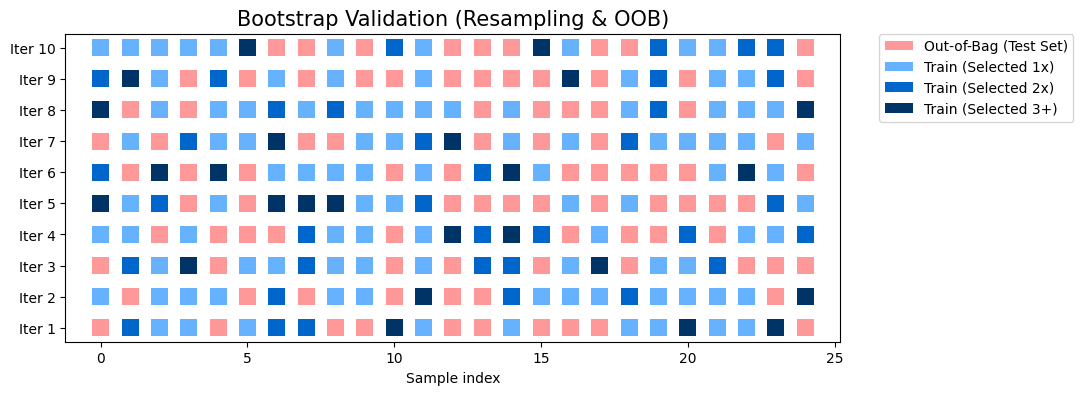

Checking for train/test overlap (Should be 0 for OOB testing):
  Overlap count: 0
  Overlap count: 0
  Overlap count: 0
  Overlap count: 0
  Overlap count: 0
  Overlap count: 0
  Overlap count: 0
  Overlap count: 0
  Overlap count: 0
  Overlap count: 0


In [121]:
# Initialize
cv = BootstrapValidation(n_iterations=10, random_state=42)

# Visualize (Note: Train samples can repeat, Test samples are unique OOB)
fig, ax = plt.subplots(figsize=(10, 4))
plot_bootcv_detailed(cv, X_small, y_small, ax, n_splits=10)
plt.show()

# Check overlap (Leakage check mechanism)
print("Checking for train/test overlap (Should be 0 for OOB testing):")
for train, test in cv.split(X_small):
    overlap = set(train).intersection(set(test))
    print(f"  Overlap count: {len(overlap)}")

### G. Leave-One-Out (LOOCV)



Each sample is used exactly once as a test set.

- **Use case:** Very small datasets (N < 50). High computational cost for large N.

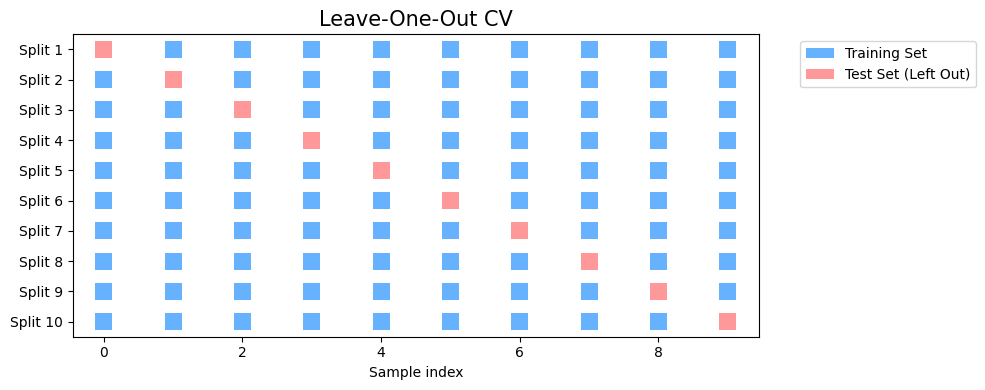

In [122]:
# Initialize
cv = LeaveOneOut()

# Visualize (Using only first 10 samples for clarity)
X_tiny = X[:10]
y_tiny = y[:10]

# 
fig, ax = plt.subplots(figsize=(10, 4))
plot_cv_detailed(cv, X_tiny, X_tiny, ax, n_splits=10)
ax.set_title('Leave-One-Out CV', fontsize=15)
plt.tight_layout()
plt.show()

### H. Leave-P-Out (LPOCV) / LeavePOut



This method leaves `p` samples out for the test set. Unlike LOOCV, this is exhaustive for groups of size `p`, which leads to a massive number of splits ($N \choose p$).

- **Use case:** Theoretical validation on tiny datasets ($N < 20$) where you need to test every possible combination.

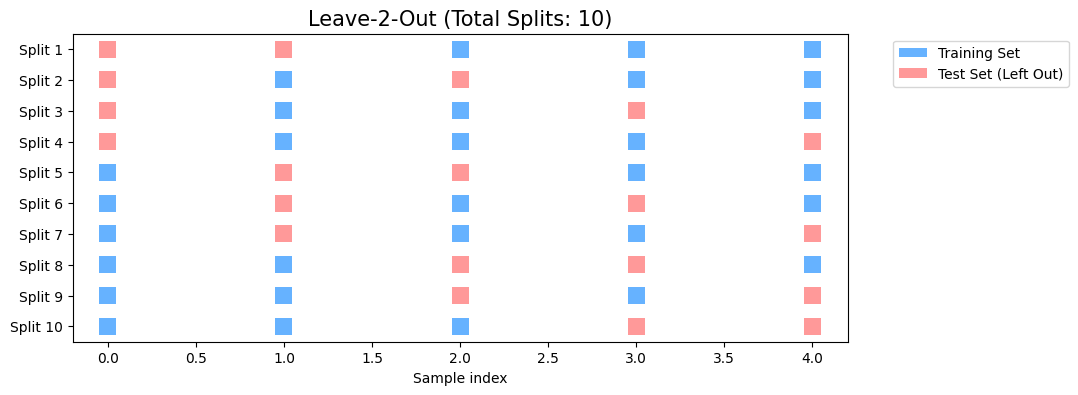

In [125]:
# Initialize
# WARNING: Combinatorial explosion risk! 
# With N=10 and p=2, we get 10 splits. With N=100, p=2, we get 4950 splits!
from math import comb


p_val = 2
cv = LeavePOut(p=p_val)

# Visualize using the tiny dataset (N=10)
X_tiny = X[:5]
y_tiny = y[:5]

# Calculate total expected splits: 5 choose 2 = 10
total_splits = comb(len(X_tiny), p_val)

fig, ax = plt.subplots(figsize=(10, 4))
plot_cv_detailed(cv, X_tiny, X_tiny, ax, n_splits=total_splits) # Explicitly set high n_splits
ax.set_title(f'Leave-{p_val}-Out (Total Splits: {cv.get_n_splits(X_tiny)})', fontsize=15)
plt.show()



### I. Nested Cross-Validation



**Nested CV** is different from the others. It is not just a splitter; it is a **validation procedure** that runs an "Inner Loop" (for hyperparameter tuning) and an "Outer Loop" (for error estimation).

- **Use case:** Reliable performance estimation when you are also tuning hyperparameters. Prevents "overfitting to the test fold."
- **Note:** Since `NestedCV` runs a full training process, we cannot plot it with `plot_cv_indices`. Instead, we run a functional example.

### Visualization Code


To visualize Nested Cross-Validation, we need a different approach because it has two layers of splitting happening simultaneously (Outer Loop for evaluation, Inner Loop for tuning).

The standard plot only shows one layer. To "see" Nested CV with the same visual pattern, we need to stack the plots: showing the Outer Split followed immediately by the Inner Splits that happen inside it.

### How to Read This Plot



1. **Outer Rows (Top Level):**
   - **Red:** The final test set for this fold. The model will eventually be tested here.
   - **Blue:** The data available for training and tuning.
2. **Inner Rows (Indented):**
   - These rows show what happens *inside* the Blue training block.
   - **Gray:** Notice the Outer Test data becomes Gray. This confirms **Safety**: the inner loop (grid search) *cannot see* the outer test set.
   - **Red/Blue split:** The Outer Train data is split again to find the best hyperparameters.

In [127]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_classification
from sklearn.model_selection import KFold
from trustcv.splitters import NestedCV

def plot_nested_cv_detailed(nested_cv, X, y, ax, lw=10):
    """
    Visualizes Nested CV by expanding Outer and Inner loops.
    
    Colors:
    - Red:    Test Set (Outer or Inner)
    - Blue:   Training Set
    - Gray:   Excluded/Ignored (Outer Test set during Inner Loop)
    """
    # Custom Colormap: 0=Test(Red), 1=Train(Blue), 2=Excluded(Gray)
    cmap = ListedColormap(['#FF9999', '#0066CC', '#E0E0E0'])
    
    # We will collect all rows (Outer + Inner) to plot at once
    plot_data = []
    y_labels = []
    
    # 1. Iterate through Outer Folds
    outer_splits = list(nested_cv.outer_cv.split(X, y))
    
    for i, (outer_train, outer_test) in enumerate(outer_splits):
        # --- A. Outer Split Row ---
        indices = np.array([np.nan] * len(X))
        indices[outer_train] = 1  # Blue (Train)
        indices[outer_test]  = 0  # Red (Test)
        
        plot_data.append(indices)
        y_labels.append(f"Outer {i+1}")
        
        # --- B. Inner Split Rows (Inside the Outer Train) ---
        # We only split the 'outer_train' data for the inner loop
        X_inner = X[outer_train]
        y_inner = y[outer_train]
        
        # Map inner indices back to original dataset positions
        original_indices_map = outer_train
        
        inner_splits = list(nested_cv.inner_cv.split(X_inner, y_inner))
        
        for j, (inner_train, inner_test) in enumerate(inner_splits):
            # Start with everything "Excluded" (Gray)
            inner_indices = np.full(len(X), 2.0) 
            
            # Map inner split back to global indices
            global_train = original_indices_map[inner_train]
            global_test  = original_indices_map[inner_test]
            
            inner_indices[global_train] = 1 # Blue (Inner Train)
            inner_indices[global_test]  = 0 # Red (Inner Test)
            # (Outer Test remains 2/Gray)
            
            plot_data.append(inner_indices)
            y_labels.append(f"  Inner {i+1}.{j+1}")
            
        # Add a spacer row (optional, represented by NaNs)
        plot_data.append(np.full(len(X), np.nan))
        y_labels.append("")

    # --- Plotting ---
    n_total_rows = len(plot_data)
    for idx, row_data in enumerate(plot_data):
        # Skip spacer rows
        if np.all(np.isnan(row_data)):
            continue
            
        ax.scatter(range(len(X)), [idx + 0.5] * len(X),
                   c=row_data, marker='s', s=150, cmap=cmap,
                   vmin=0, vmax=2, edgecolors='none')

    # Formatting
    ax.set_yticks(np.arange(n_total_rows) + 0.5)
    ax.set_yticklabels(y_labels)
    ax.set_xlabel('Sample index')
    ax.set_ylim(n_total_rows, 0) # Invert Y axis
    ax.set_title('Nested Cross-Validation Structure', fontsize=15)
    
    # Legend
    legend_elements = [
        Patch(facecolor='#0066CC', label='Train'),
        Patch(facecolor='#FF9999', label='Test (Validation)'),
        Patch(facecolor='#E0E0E0', label='Held-out (Outer Test)')
    ]
    ax.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left')
    return ax



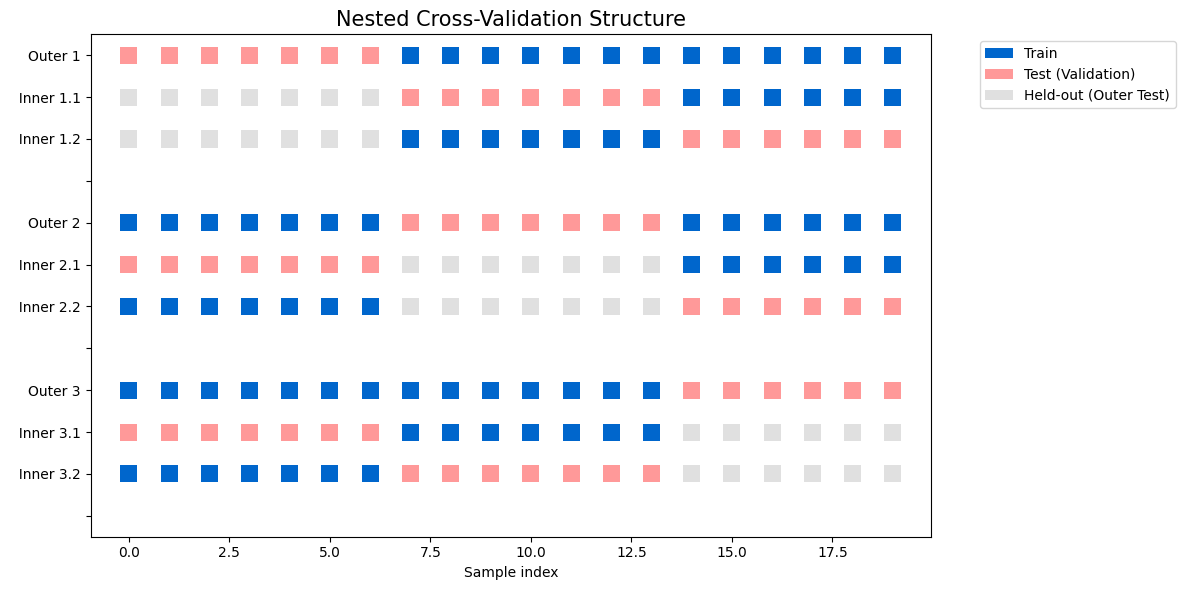

In [131]:
# --- Setup & Run ---
# 1. Create Data
# Visualize (Using only first 10 samples for clarity)
X_tiny = X[:20]
y_tiny = y[:20]

# 2. Define Nested CV (3 Outer, 2 Inner for readability)
nested = NestedCV(
    outer_cv=KFold(n_splits=3),
    inner_cv=KFold(n_splits=2)
)

# 3. Plot
fig, ax = plt.subplots(figsize=(12, 6))
plot_nested_cv_detailed(nested, X_tiny, y_tiny, ax)
plt.tight_layout()
plt.show()

## 5. Integrated Validation Example



Finally, we demonstrate how to use these splitters inside the `TrustCVValidator`, which adds automated checks for data leakage and class balance.

In [4]:
from sklearn.datasets import load_breast_cancer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

# Load data
X, y = load_breast_cancer(return_X_y=True)

# Baseline model (any sklearn estimator with fit/predict will work)
model = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(random_state=42)
)

X.shape, y.shape

((569, 30), (569,))

## A. Hold-Out Validation

In [ ]:
validator = TrustCVValidator(
    method="HoldOut",  # IID, stratified
    test_size=0.2,
    stratify=None,  # For classification tasks, use "True" to stratify by labels
    random_state=42,
    check_leakage=True,
    check_balance=True,
    #metrics=["accuracy", "roc_auc", "f1"],
    return_confidence_intervals=True,
    ci_method='t-interval', # 'bootstrap' or 't-interval'
    ci_level=0.95, # confidence level for intervals
    
)


val_result = validator.validate(model=model, X=X, y=y )
print(val_result.summary())

=== Trustworthy Cross-Validation Results ===

Performance Metrics (mean +/- std) (method: t-interval):
  accuracy: 0.965 +/- 0.000 [95% CI: n/a]
  roc_auc: 0.996 +/- 0.000 [95% CI: n/a]
  sensitivity: 0.986 +/- 0.000 [95% CI: n/a]
  specificity: 0.929 +/- 0.000 [95% CI: n/a]
  precision: 0.959 +/- 0.000 [95% CI: n/a]
  recall: 0.986 +/- 0.000 [95% CI: n/a]
  f1: 0.972 +/- 0.000 [95% CI: n/a]

Data Integrity Checks:
  Leakage Check: PASSED
  Class Balance: PASSED



## B. K-Fold Cross-Validation

In [136]:
validator = TrustCVValidator(
    method="Kfold",  # IID, stratified
    n_splits=5,
    random_state=42,
    check_leakage=True,
    check_balance=True,
    #metrics=["accuracy", "roc_auc", "f1"],
    return_confidence_intervals=True,
    ci_method='t-interval', # 'bootstrap' or 't-interval'
    ci_level=0.95, # confidence level for intervals
     
)


val_result = validator.validate(model=model, X=X, y=y )
print(val_result.summary())

=== Trustworthy Cross-Validation Results ===

Performance Metrics (mean +/- std) (method: t-interval):
  accuracy: 0.960 +/- 0.008 [95% CI (t-interval): 0.950-0.969]
  roc_auc: 0.987 +/- 0.014 [95% CI (t-interval): 0.970-1.005]
  sensitivity: 0.969 +/- 0.012 [95% CI (t-interval): 0.955-0.984]
  specificity: 0.944 +/- 0.020 [95% CI (t-interval): 0.919-0.968]
  precision: 0.966 +/- 0.013 [95% CI (t-interval): 0.950-0.982]
  recall: 0.969 +/- 0.012 [95% CI (t-interval): 0.955-0.984]
  f1: 0.968 +/- 0.006 [95% CI (t-interval): 0.960-0.976]

Data Integrity Checks:
  Leakage Check: PASSED
  Class Balance: PASSED



## C. Stratified K-Fold (Medical Recommended)

In [137]:
validator = TrustCVValidator(
    method="stratifiedKfold",  # IID, stratified
    n_splits=5,
    random_state=42,
    check_leakage=True,
    check_balance=True,
    #metrics=["accuracy", "roc_auc", "f1"],
    return_confidence_intervals=True,
    ci_method='t-interval', # 'bootstrap' or 't-interval'
    ci_level=0.95, # confidence level for intervals
     
)


val_result = validator.validate(model=model, X=X, y=y )
print(val_result.summary())

=== Trustworthy Cross-Validation Results ===

Performance Metrics (mean +/- std) (method: t-interval):
  accuracy: 0.956 +/- 0.014 [95% CI (t-interval): 0.939-0.973]
  roc_auc: 0.989 +/- 0.009 [95% CI (t-interval): 0.977-1.000]
  sensitivity: 0.966 +/- 0.030 [95% CI (t-interval): 0.929-1.004]
  specificity: 0.939 +/- 0.056 [95% CI (t-interval): 0.869-1.009]
  precision: 0.965 +/- 0.031 [95% CI (t-interval): 0.926-1.004]
  recall: 0.966 +/- 0.030 [95% CI (t-interval): 0.929-1.004]
  f1: 0.965 +/- 0.011 [95% CI (t-interval): 0.952-0.979]

Data Integrity Checks:
  Leakage Check: PASSED
  Class Balance: PASSED



## D. Repeated K-Fold

In [ ]:
from trustcv import TrustCVValidator

validator = TrustCVValidator(
    method="RepeatedKFold",  # IID, stratified
    n_splits=5,
    n_repeats=3,
    random_state=42,
    check_leakage=True,
    check_balance=True,
    stratify=True,  # With stratification
    #metrics=["accuracy", "roc_auc", "f1"],
    return_confidence_intervals=True,
    ci_method='t-interval', # 'bootstrap' or 't-interval'
    ci_level=0.95, # confidence level for intervals
)
val_result = validator.validate(model=model, X=X, y=y )
print(val_result.summary())

=== Trustworthy Cross-Validation Results ===

Performance Metrics (mean +/- std) (method: t-interval):
  accuracy: 0.959 +/- 0.025 [95% CI (t-interval): 0.945-0.973]
  roc_auc: 0.989 +/- 0.009 [95% CI (t-interval): 0.984-0.995]
  sensitivity: 0.973 +/- 0.026 [95% CI (t-interval): 0.959-0.987]
  specificity: 0.936 +/- 0.055 [95% CI (t-interval): 0.905-0.966]
  precision: 0.963 +/- 0.031 [95% CI (t-interval): 0.946-0.980]
  recall: 0.973 +/- 0.026 [95% CI (t-interval): 0.959-0.987]
  f1: 0.968 +/- 0.019 [95% CI (t-interval): 0.957-0.978]

Data Integrity Checks:
  Leakage Check: PASSED
  Class Balance: PASSED



### RepeatedKFold with no stratification

In [ ]:
from trustcv import TrustCVValidator

validator = TrustCVValidator(
    method="RepeatedKFold",  # IID, stratified
    n_splits=5,
    n_repeats=3,
    random_state=42,
    check_leakage=True,
    check_balance=True,
    stratify=False,  # with no stratification
    #metrics=["accuracy", "roc_auc", "f1"],
    return_confidence_intervals=True,
    ci_method='t-interval', # 'bootstrap' or 't-interval'
    ci_level=0.95, # confidence level for intervals
)
val_result = validator.validate(model=model, X=X, y=y )
print(val_result.summary())

=== Trustworthy Cross-Validation Results ===

Performance Metrics (mean +/- std) (method: t-interval):
  accuracy: 0.959 +/- 0.019 [95% CI (t-interval): 0.949-0.969]
  roc_auc: 0.989 +/- 0.010 [95% CI (t-interval): 0.983-0.994]
  sensitivity: 0.971 +/- 0.016 [95% CI (t-interval): 0.962-0.980]
  specificity: 0.939 +/- 0.035 [95% CI (t-interval): 0.919-0.959]
  precision: 0.964 +/- 0.021 [95% CI (t-interval): 0.952-0.975]
  recall: 0.971 +/- 0.016 [95% CI (t-interval): 0.962-0.980]
  f1: 0.967 +/- 0.015 [95% CI (t-interval): 0.959-0.976]

Data Integrity Checks:
  Leakage Check: PASSED
  Class Balance: PASSED



## E. Monte Carlo CV (Shuffle-Split)



In [139]:
validator = TrustCVValidator(
    method="MonteCarloCV",  # IID, stratified
    n_iterations=50,
    test_size=0.2,
    random_state=42,
    check_leakage=True,
    check_balance=True,
    #metrics=["accuracy", "roc_auc", "f1"],
    return_confidence_intervals=True,
    ci_method='t-interval', # 'bootstrap' or 't-interval'
    ci_level=0.95, # confidence level for intervals
    
)


val_result = validator.validate(model=model, X=X, y=y )
print(val_result.summary())

=== Trustworthy Cross-Validation Results ===

Performance Metrics (mean +/- std) (method: t-interval):
  accuracy: 0.961 +/- 0.019 [95% CI (t-interval): 0.955-0.966]
  roc_auc: 0.991 +/- 0.007 [95% CI (t-interval): 0.989-0.993]
  sensitivity: 0.974 +/- 0.021 [95% CI (t-interval): 0.968-0.980]
  specificity: 0.939 +/- 0.038 [95% CI (t-interval): 0.928-0.949]
  precision: 0.963 +/- 0.024 [95% CI (t-interval): 0.956-0.969]
  recall: 0.974 +/- 0.021 [95% CI (t-interval): 0.968-0.980]
  f1: 0.968 +/- 0.016 [95% CI (t-interval): 0.964-0.973]

Data Integrity Checks:
  Leakage Check: PASSED
  Class Balance: PASSED



## F. Bootstrap Validation



In [140]:
validator = TrustCVValidator(
    method="BootstrapValidation",  # IID, stratified
    n_iterations=100,
    bootstrap_estimator='.632',  # try 'standard', '.632', '.632+'
    random_state=42,
    check_leakage=True,
    check_balance=True,
    #metrics=["accuracy", "roc_auc", "f1"],
    return_confidence_intervals=True,
    ci_method='t-interval', # 'bootstrap' or 't-interval'
    ci_level=0.95, # confidence level for intervals
    
)


val_result = validator.validate(model=model, X=X, y=y )
print(val_result.summary())

=== Trustworthy Cross-Validation Results ===

Performance Metrics (mean +/- std) (method: t-interval):
  accuracy: 0.959 +/- 0.014 [95% CI (t-interval): 0.957-0.961]
  roc_auc: 0.989 +/- 0.006 [95% CI (t-interval): 0.989-0.990]
  sensitivity: 0.974 +/- 0.015 [95% CI (t-interval): 0.972-0.976]
  specificity: 0.933 +/- 0.028 [95% CI (t-interval): 0.929-0.937]
  precision: 0.961 +/- 0.017 [95% CI (t-interval): 0.959-0.963]
  recall: 0.974 +/- 0.015 [95% CI (t-interval): 0.972-0.976]
  f1: 0.967 +/- 0.011 [95% CI (t-interval): 0.966-0.969]

Data Integrity Checks:
  Leakage Check: PASSED
  Class Balance: PASSED




## I. Nested Cross-Validation

TrustCVValidator doesn’t embed a nested-loop tuner today, so you can’t just pass method='NestedCV' and have it wire up inner/outer splitters. 

So if you need nested cross-validation:

Keep using the dedicated helper:

In [7]:
from sklearn.datasets import load_breast_cancer
from trustcv import KFold, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from trustcv import TrustCVValidator

from trustcv import NestedCV

data = load_breast_cancer()
X, y = data.data, data.target

outer_cv = KFold(n_splits=3, shuffle=True, random_state=1)
inner_cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=2)

model = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(random_state=42),
)

param_grid = {
    "randomforestclassifier__n_estimators": [50, 100],
    "randomforestclassifier__max_depth": [None, 5],
}

nested = NestedCV(outer_cv=outer_cv, inner_cv=inner_cv)
scores, best_params = nested.fit_predict(model, X, y, param_grid)

print("Nested CV scores:", scores)
print("Best params per outer fold:", best_params)


Nested CV scores: [0.9368421052631579, 0.9473684210526315, 0.9682539682539683]
Best params per outer fold: [{'randomforestclassifier__max_depth': None, 'randomforestclassifier__n_estimators': 100}, {'randomforestclassifier__max_depth': 5, 'randomforestclassifier__n_estimators': 100}, {'randomforestclassifier__max_depth': None, 'randomforestclassifier__n_estimators': 100}]


### Recomandation

For TrustCV-style summaries (multiple metrics, leakage/balance status, formatted report), you’d need to run TrustCVValidator separately—NestedCV doesn’t currently integrate with it. One approach is:

1. Use NestedCV to select hyperparameters (e.g., average the best_params or pick the most frequent).
2. Instantiate a model with that configuration.
3. Pass the tuned model into TrustCVValidator(method='stratified_kfold', …) to generate the full report with confidence intervals.

**That keeps NestedCV focused on model selection while TrustCVValidator handles the rich diagnostics.** 

In [9]:
model = make_pipeline(
    StandardScaler(),
    RandomForestClassifier( max_depth= None, n_estimators= 100, random_state=42),
)

validator = TrustCVValidator(
    method="StratifiedKFold",  # IID, stratified
    n_splits=5,
    random_state=42,
    check_leakage=True,
    check_balance=True,
    #metrics=["accuracy", "roc_auc", "f1"],
    return_confidence_intervals=True,
    ci_method='t-interval', # 'bootstrap' or 't-interval'
    ci_level=0.95, # confidence level for intervals
     
)


val_result = validator.validate(model=model, X=X, y=y )
print(val_result.summary())

=== Trustworthy Cross-Validation Results ===

Performance Metrics (mean +/- std) (method: t-interval):
  accuracy: 0.956 +/- 0.014 [95% CI (t-interval): 0.939-0.973]
  roc_auc: 0.989 +/- 0.009 [95% CI (t-interval): 0.977-1.000]
  sensitivity: 0.966 +/- 0.030 [95% CI (t-interval): 0.929-1.004]
  specificity: 0.939 +/- 0.056 [95% CI (t-interval): 0.869-1.009]
  precision: 0.965 +/- 0.031 [95% CI (t-interval): 0.926-1.004]
  recall: 0.966 +/- 0.030 [95% CI (t-interval): 0.929-1.004]
  f1: 0.965 +/- 0.011 [95% CI (t-interval): 0.952-0.979]

Data Integrity Checks:
  Leakage Check: PASSED
  Class Balance: PASSED



## G. Leave-One-Out (LOOCV)

Because LOOCV/LPOCV explode quickly, I slice the dataset down to 80 samples for LOOCV and 80 for Leave-2-Out—feel free to bump those numbers back up if you’re patient.

In [10]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

from trustcv import TrustCVValidator

data = load_breast_cancer()
X, y = data.data, data.target

model = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(n_estimators=200, random_state=42),
)

# --- Leave-One-Out CV (LOOCV) ---
validator_loocv = TrustCVValidator(
    method='LOOCV',               # alias wired to the loocv splitter
    check_leakage=True,
    check_balance=True,
    return_confidence_intervals=True,
    ci_method='t-interval',
    ci_level=0.95,
)

# Use a manageable slice; LOOCV cost is O(n)
X_loocv, y_loocv = X[:80], y[:80]
result_loocv = validator_loocv.validate(model=model, X=X_loocv, y=y_loocv)
print("=== LOOCV ===")
print(result_loocv.summary())




/home/amir/Umea_Desctop/AAA_test/p4_CV/P4_paper/Repo/trustcv-main_v1/.venv/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/amir/Umea_Desctop/AAA_test/p4_CV/P4_paper/Repo/trustcv-main_v1/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/amir/Umea_Desctop/AAA_test/p4_CV/P4_paper/Repo/trustcv-main_v1/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[

=== LOOCV ===
=== Trustworthy Cross-Validation Results ===

Performance Metrics (mean +/- std) (method: t-interval):
  accuracy: 0.925 +/- 0.265 [95% CI (t-interval): 0.866-0.984]
  roc_auc: nan +/- nan [95% CI: n/a]
  sensitivity: 0.263 +/- 0.443 [95% CI (t-interval): 0.164-0.361]
  specificity: 0.662 +/- 0.476 [95% CI (t-interval): 0.557-0.768]
  precision: 0.263 +/- 0.443 [95% CI (t-interval): 0.164-0.361]
  recall: 0.263 +/- 0.443 [95% CI (t-interval): 0.164-0.361]
  f1: 0.263 +/- 0.443 [95% CI (t-interval): 0.164-0.361]

Data Integrity Checks:
  Leakage Check: PASSED
  Class Balance: PASSED



/home/amir/Umea_Desctop/AAA_test/p4_CV/P4_paper/Repo/trustcv-main_v1/.venv/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


## H. Leave-P-Out (LPOCV) / LeavePOut

In [11]:
# --- Leave-p-Out CV (LPOCV) ---
validator_lpocv = TrustCVValidator(
    method='LPOCV',               # alias for leave-p-out splitter
    p=2,                          # new alias hooks into lpocv_p
    check_leakage=True,
    check_balance=True,
    return_confidence_intervals=True,
    ci_method='t-interval',
    ci_level=0.95,
)

# Again, keep n modest: LPOCV runs comb(n, p) splits
X_lpocv, y_lpocv = X[:80], y[:80]
result_lpocv = validator_lpocv.validate(model=model, X=X_lpocv, y=y_lpocv)
print("\n=== Leave-2-Out ===")
print(result_lpocv.summary())

/home/amir/Umea_Desctop/AAA_test/p4_CV/P4_paper/Repo/trustcv-main_v1/trustcv/splitters/iid.py:291: UserWarning: LPOCV will generate 3160 iterations. This may be computationally expensive.
  warnings.warn(
/home/amir/Umea_Desctop/AAA_test/p4_CV/P4_paper/Repo/trustcv-main_v1/.venv/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/amir/Umea_Desctop/AAA_test/p4_CV/P4_paper/Repo/trustcv-main_v1/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/amir/Umea_Desctop/AAA_test/p4_CV/P4_paper/Repo/trustcv-main_v1/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetric


=== Leave-2-Out ===
=== Trustworthy Cross-Validation Results ===

Performance Metrics (mean +/- std) (method: t-interval):
  accuracy: 0.931 +/- 0.176 [95% CI (t-interval): 0.925-0.937]
  roc_auc: nan +/- nan [95% CI: n/a]
  sensitivity: 0.450 +/- 0.493 [95% CI (t-interval): 0.433-0.467]
  specificity: 0.871 +/- 0.318 [95% CI (t-interval): 0.860-0.882]
  precision: 0.452 +/- 0.493 [95% CI (t-interval): 0.434-0.469]
  recall: 0.450 +/- 0.493 [95% CI (t-interval): 0.433-0.467]
  f1: 0.448 +/- 0.489 [95% CI (t-interval): 0.431-0.465]

Data Integrity Checks:
  Leakage Check: PASSED
  Class Balance: PASSED

